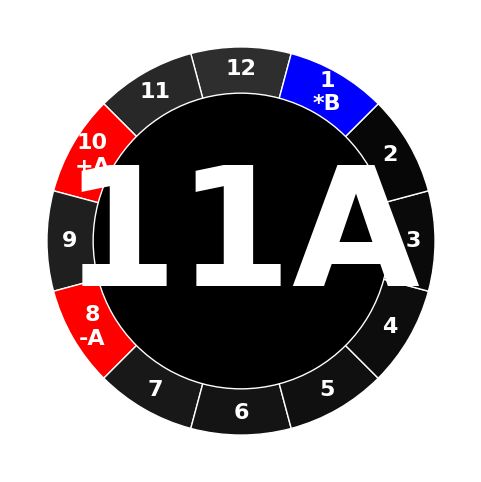

In [19]:
import matplotlib.pyplot as plt
import numpy as np

def create_donut_plot(inner_color, outer_colors, set_plus, set_minus, set_scale):
    """
    Creates a donut plot with a black inner circle and an outer circle with highlighted partitions.

    Parameters:
    - inner_color: Color of the inner circle.
    - outer_colors: List of colors for the outer circle.
    - set_plus: Number and letter (e.g., "12A") to mark with a '+'.
    - set_minus: Number and letter (e.g., "2A") to mark with a '-'.
    - set_scale: Number and letter (e.g., "4B") to mark with an 'X'.
    """
    # Parse the inputs for numbers and colors
    set_plus_num, set_plus_letter = int(set_plus[:-1]), set_plus[-1]
    set_minus_num, set_minus_letter = int(set_minus[:-1]), set_minus[-1]
    set_scale_num, set_scale_letter = int(set_scale[:-1]), set_scale[-1]

    # Color mappings for letters
    color_map = {'A': 'red', 'B': 'blue'}

    # Adjust rotation so the first color fully faces up
    adjusted_rotation_angle = 90 - (360 / 24)  # Slight adjustment to center the first partition

    # Highlight partitions dynamically
    highlighted_colors = []
    for i in range(12):
        number = 12 - i if i != 0 else 12
        if number == set_plus_num:
            highlighted_colors.append(color_map.get(set_plus_letter, 'black'))
        elif number == set_minus_num:
            highlighted_colors.append(color_map.get(set_minus_letter, 'black'))
        elif number == set_scale_num:
            highlighted_colors.append(color_map.get(set_scale_letter, 'black'))
        else:
            highlighted_colors.append(outer_colors[i])

    # Create figure and axes
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(aspect="equal"))

    # Plot the inner circle
    ax.pie([1],  # Single partition for the inner circle
           radius=0.9,
           labels=None,
           colors=[inner_color],
           startangle=0,
           wedgeprops=dict(width=0.9, edgecolor='w'))

    # Plot the outer circle with adjusted rotation fffff
    outer_radius = 1.05
    ax.pie([1] * 12,  # Exactly 12 partitions
           radius=outer_radius,
           labels=None,  # No labels
           colors=highlighted_colors,
           startangle=adjusted_rotation_angle,
           wedgeprops=dict(width=outer_radius - 0.8, edgecolor='w'))

    # Remove title and set square aspect
    ax.set(aspect="equal")
    plt.axis('off')  # Hide axes

    return ax, adjusted_rotation_angle, outer_radius  # Return the axes and other parameters for customization

def add_clock_numbers_with_styles(ax, adjusted_rotation_angle, outer_radius, rotation_offset, 
                                   set_plus, set_minus, set_scale, key_song):
    """
    Adds clock numbers (12 to 1) with customized styles based on inputs for '+' (set_plus), '-' (set_minus), 
    and 'X' (set_scale), including the associated letter (A or B). Places the key_song string in the center.

    Parameters:
    - ax: The axes object returned from the donut plot.
    - adjusted_rotation_angle: The starting angle for the plot.
    - outer_radius: The radius of the outer circle for positioning the numbers.
    - rotation_offset: Additional angle (in degrees) to rotate the numbers to the left.
    - set_plus: Number and letter (e.g., "12A") to mark with a '+'.
    - set_minus: Number and letter (e.g., "2A") to mark with a '-'.
    - set_scale: Number and letter (e.g., "4B") to mark with an 'X'.
    - key_song: String to be placed in the center of the circle.
    """
    # Parse the inputs for numbers and colors
    set_plus_num, set_plus_letter = int(set_plus[:-1]), set_plus[-1]
    set_minus_num, set_minus_letter = int(set_minus[:-1]), set_minus[-1]
    set_scale_num, set_scale_letter = int(set_scale[:-1]), set_scale[-1]

    angle_step = 360 / 12  # Step size for each partition
    angles = np.arange(0, 360, angle_step) + adjusted_rotation_angle + rotation_offset  # Adjusted angles
    text_radius = outer_radius - 0.12 # Slightly inward from the outer edge

    # Overlay numbers in clockwise order (12 to 1)
    for i, angle in enumerate(angles):
        number = 12 - i if i != 0 else 12
        x = text_radius * np.cos(np.radians(angle))
        y = text_radius * np.sin(np.radians(angle))

        # Determine the style based on the input variables
        if number == set_plus_num:
            symbol = f"\n+{set_plus_letter}"
        elif number == set_minus_num:
            symbol = f"\n-{set_minus_letter}"
        elif number == set_scale_num:
            symbol = f"\n*{set_scale_letter}"
        else:
            symbol = ''

        # Add text with white font for visibility
        ax.text(x, y, f"{number}{symbol}", ha='center', va='center', fontsize=16, weight='bold', color='white')

    # Add key_song in the center of the circle with white font and font size 30
    ax.text(0, 0, key_song, ha='center', va='center', fontsize=119, weight='bold', color='white')

# Example usage

inner_circle_color = '#000000'  # Black for the inner circle
outer_circle_colors = [
    "#2E2E2E",  # Dark Gray
    "#282828",  # Charcoal Gray
    "#242424",  # Jet Black
    "#1F1F1F",  # Dark Gunmetal
    "#1B1B1B",  # Onyx
    "#181818",  # Eerie Black
    "#141414",  # Black Olive
    "#101010",  # Smoky Black
    "#0D0D0D",  # Outer Space Black
    "#0A0A0A",  # Licorice
    "#070707",  # Rich Black
    "#000000"   # Pure Black
]

# Define the variables for styling
set_plus = "10A"
set_minus = "8A"
set_scale = "1B"
key_song = "11A"  # Key song to be placed in the center
rotation_offset = 15

# Create the donut plot
ax, adjusted_rotation_angle, outer_radius = create_donut_plot(inner_circle_color, outer_circle_colors, set_plus, set_minus, set_scale)

# Add clock numbers with styles and the key_song
add_clock_numbers_with_styles(ax, adjusted_rotation_angle, outer_radius, rotation_offset, 
                               set_plus, set_minus, set_scale, key_song)



# Show the plot
plt.savefig( f"try.png", format="png", dpi=300)  # You can specify the filename, format, and DPI

#plt.show()


In [20]:
from PIL import Image

# Path to the input and output images
input_path = f"try.png"
output_path = f"try.png"

# Open the image
image = Image.open(input_path).convert("RGBA")

# Set the tolerance for detecting white shades
tolerance = 200  # Adjust this value for more/less aggressive removal

# Get image data
data = image.getdata()
new_data = []

# Iterate over each pixel
for item in data:
    # Calculate the brightness of the pixel
    brightness = sum(item[:3]) / 3  # Average of R, G, B
    if brightness > tolerance:  # Threshold for "white"
        # Replace white/near-white with transparency
        new_data.append((255, 255, 255, 0))
    else:
        new_data.append(item)

# Update the image with the new data
image.putdata(new_data)
image.save(output_path, "PNG")

print(f"Image saved to {output_path} with a cleaned background.")


Image saved to try.png with a cleaned background.


In [21]:
%run _key_add_fns.py

In [22]:
path = f"test.aiff"
extract_aiff_cover(path)

Cover extracted, resized, framed, and saved as test.jpg
Resized and framed cover embedded back into the AIFF file.


True

In [23]:
######## ID

# Define path to the AIFF file
#aiff_file_path = path


# # Run the function with larger text
# _process_cover_art_with_circle(
#     aiff_file_path, 
#     circle_size_ratio=0.25,  # Keep Circle size as 25% of cover art
#     position="bottom-right", 
#     circle_color=(0, 0, 0, 255),  # Black Circle
#     text_color=(255, 255, 255, 255),  # White Key Text
#     key="ai23",
#     text_scale=0.5  # Larger text size
# )

######## bpm

# Define path to the AIFF file
aiff_file_path = path


# Run the function with larger text
_process_cover_art_with_circle(
    aiff_file_path, 
    circle_size_ratio=0.25,  # Keep Circle size as 25% of cover art
    position="top-left", 
    circle_color=(0, 0, 0, 225),  # White
    text_color=(0, 255, 25, 255),  # green
    key="123",
    text_scale=0.5  # Larger text size
)

# Run the function with larger text
_process_cover_art_with_circle(
    aiff_file_path, 
    circle_size_ratio=0.33,  # Keep Circle size as 25% of cover art
    position="top-right", 
    circle_color=(255, 255, 255, 255),  # Black Circle
    text_color=(0, 255, 25, 255),  # White Key Text
    key="",
    text_scale=0.5  # Larger text size
)


Processed cover image saved at test.jpg
Processed cover image saved at test.jpg


In [25]:
embed_cover_into_aiff(path, f"test.jpg")

Updated existing cover tag.
Cover image successfully embedded in test.aiff


In [26]:
from PIL import Image


# Load the two images
background = Image.open(f"test.jpg")
overlay = Image.open(f"try.png")

# Resize the overlay image to make it smaller
resize_factor = 0.265  # Adjust this factor to scale the overlay
overlay_resized = overlay.resize(
    (int(overlay.width * resize_factor), int(overlay.height * resize_factor))
)

# Position variables
dpi = 300  # Dots per inch
cm_to_pixels = lambda cm: int(cm * dpi / 2.54)

# Adjust these numbers for position
position_right_cm = -0.232 # Distance from the right edge in cm
position_top_cm = -.59 # Distance from the top edge in cm (touching the edge)

x_offset = background.width - overlay_resized.width - cm_to_pixels(position_right_cm)
y_offset = cm_to_pixels(position_top_cm)  # Distance from the top edge

# Ensure image modes match for pasting
if overlay_resized.mode != 'RGBA':
    overlay_resized = overlay_resized.convert('RGBA')

# Paste the overlay onto the background
background.paste(overlay_resized, (x_offset, y_offset), overlay_resized)

# Save and/or display the result
background.save(f"test.jpg")
#background.show()


# next 

In [28]:
# LUFS AND EMBED 



# Example usage
_overlay_circle_custom_0501_GET_image(
    input_string="Lue",  # Extracts 'e' from this string
    image_path=f"test.jpg", 
    circle_position=(-0.379, -1.2098003),  # Center horizontally, near the top
    circle_diameter=2770          # Custom diamete
)


# Example usage
_overlay_circle_custom_0501_GET_image(
    input_string="Lue",  # Extracts 'e' from this string
    image_path=f"test.jpg", 
    circle_position=(-0.379, -1.2098003),  # Center horizontally, near the top
    circle_diameter=2755          # Custom diamete
)
